In [82]:
import os
import sys
import math
import datetime
import numpy as np
from numpy.random import randint, uniform
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

from functools import partial
from joblib import Parallel, delayed

import healpy as hp
import camb

from ksw import Cosmology, Data
from ksw.radial_functional import radial_func

from tqdm.auto import tqdm
from pixell import enmap, lensing, curvedsky
import lenspyx


import sys
sys.path.append('datagen/')
from utils import MemoryMonitor, load_data, save_data, save_plt, get_radii, plot_cl_map, plot_cl_alm
from config import SimConfig

# %matplotlib inline


In [74]:
config_file = 'settings/cmb-s4-single.json'
s = SimConfig(config_file)

if s.debug:
    monitor = MemoryMonitor()

def vp(*args, **kwargs):
    if s.verbose:
        print(f'{datetime.datetime.now()}:', *args, **kwargs)

Loaded settings from file: settings/cmb-s4-single.json
{ 'alm_cache_dir': 'data/alm_cache',
  'base_dir': 'data',
  'beam_width': 1.0,
  'cosmo_params': { 'AccuracyBoost': 2.0,
                    'As': 2.13e-09,
                    'DoLateRadTruncation': False,
                    'H0': 67.5,
                    'TCMB': 2.7255,
                    'lAccuracyBoost': 2.0,
                    'lSampleBoost': 2.0,
                    'lens_potential_accuracy': 2,
                    'lmax': 5000,
                    'max_l': 5500,
                    'mnu': 0.06,
                    'ns': 0.9624,
                    'ombh2': 0.02233,
                    'omch2': 0.1198,
                    'pivot_scalar': 0.05,
                    'r': 0,
                    'tau': 0.0561},
  'debug': True,
  'disable_noise': False,
  'double_precision': False,
  'fnl_range': [-1000, 1000],
  'force_alm_gen': True,
  'lensing': False,
  'name': 'cmb-s4',
  'narray': 1,
  'noise_scale_ee': 4.3,
  'noise_sc

 # Data Generator

 This code primarily uses [KSW](https://github.com/AdriJD/ksw/tree/master/src), as a means to generate non-gaussian cmb maps. These get stored in a data file with the fnls, and patches.

 The full-sky maps are generated using the method discussed in [CMB lensing and primordial non-gaussianity](https://arxiv.org/abs/0905.4732), where we find (eq. 6)
 $$
 a_{\ell m} = a_{\ell m}^{{G}} + f_{NL}^X a_{\ell m}^{NG}
 $$
 and generated the full sky map from the $a_{\ell m}$.

 Most of this code is to calculate the term (eq. 27)

 $$
 a_{\ell m}^{NG,loc'} = \int dr r^2 \left[ \alpha_\ell(r)\left(\int d^2 \hat{n} Y_{\ell m}^\star (\hat{n}) B(r,\hat{n})^2 \right)\right]
 $$

 and

 $$
 \alpha_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^2 \Delta_\ell^T(k) j_\ell(k r)
 $$

 $$
 \beta_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^{-1} \Delta_\phi \Delta_\ell^T(k) j_\ell(k r)
 $$

 $$
 B(r, \hat{n}) = \sum_{\ell,m} \frac{\beta_\ell (r)}{C_\ell} a_{\ell m} Y_{\ell m}
 $$

 where $\Delta_\phi$ is primordial normalization, $\Delta_\ell^T(k)$ is the transfer function, $j_\ell(k r)$ are the spherical bessel functions

 ---

 # $a_{\ell m}$ Calculation

 For the radii we follow Table 2. of Smith and Zaldarriaga which gives a greater density of points near reionization and recombination.

 Spacing for all ranges but the last row are linear, with the last row having log spacing.

 radii are in Mpc

In [75]:
camb_params_obj = camb.set_params(**s.cosmo_params, verbose=s.verbose)
cosmo = Cosmology(camb_params_obj, verbose=s.verbose)

# Additional settings here, i.e.
# cosmo._setattr_camb('ns', 0.9624, subclass='InitPower')

cosmo.compute_transfer(s.cosmo_params['max_l'], verbose=s.verbose)
cosmo.compute_c_ell()

noise_ell, beam_ell = s.get_noise_beam()
ksw_data = Data(s.lmax, noise_ell, beam_ell, s.polarizations, cosmo)

c_ells = ksw_data.cosmology.c_ell['unlensed_scalar'] # type: ignore

tr_ell_k = ksw_data.cosmology.transfer['tr_ell_k']
tr_ells = ksw_data.cosmology.transfer['ells']
tr_k = ksw_data.cosmology.transfer['k']

mask = (tr_ells <= s.lmax)
tr_ell_k = tr_ell_k[mask]
tr_ells = tr_ells[mask]

radii, drs = get_radii(s.settings['r_min'], s.settings['r_max'])

# TODO, check for the true final file too
if os.path.isfile(s.alm_final_file) and not s.settings['force_alm_gen']:
    vp('Found alms file, skipping alm generation')
    gen_alms = False
    if s.job_array_index is not None:
        start_idx = (int(s.job_array_index)-s.job_array_min) * s.nsims
        end_idx = start_idx + s.nsims
    else:
        start_idx = None
        end_idx = None

    alm_data = load_data(s.alm_final_file, ['alm', 'almng'], start_idx, end_idx, verbose=s.verbose)
    alms = alm_data['alm']
    almngs = alm_data['almng']
else:
    if os.path.isfile(s.alm_file):
        vp('Removing stale alm file', s.alm_file)
        os.remove(s.alm_file)

    vp('Generating new alms')
    alms = None
    almngs = None
    gen_alms = True


Updated CAMB param: BessIntBoost from 1.0 to 30.
Updated CAMB param: KmaxBoost from 1.0 to 3.
Updated CAMB param: IntTolBoost from 1.0 to 4.
Updated CAMB param: TimeStepBoost from 1.0 to 4.
Updated CAMB param: SourcekAccuracyBoost from 1.0 to 5.
Updated CAMB param: BesselBoost from 1.0 to 5.
Updated CAMB param: IntkAccuracyBoost from 1.0 to 5.
Updated CAMB param: AccurateBB from False to True.


2023-07-27 11:42:09.229537: Generating new alms


 `radial_func` computes $f_\ell^X(r) = \frac{2}{\pi} \int k^2 dk f(k) \Delta^{TX}_\ell(k) j_\ell(k r)$, we will use this to find
 $
 \alpha_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^2 \Delta_\ell^T(k) j_\ell(k r)
 $,
 and
 $
 \beta_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^{-1} \Delta_\phi \Delta_\ell^T(k) j_\ell(k r)
 $.

 $\Delta_\ell^T(k)$, the transfer functions, are calculated sparsely (in l) by CAMB; We thus need to interpolate over the missing values to get `alpha_l`, `beta_l` which are suitable for the calculations.
 We do this with `CubicSpline`, but this could be changed if needed.

 We also go ahead and calculate `bl_div_cl`=$\beta_\ell / C_\ell$, which is used to calculate $B(r,\hat{n})$.

In [76]:
if gen_alms:
    def interpolate_ells(func, ells_sparse, ls, axis=1):
        return CubicSpline(ells_sparse, func, axis)(ls)

    vp('Calculating alpha_l and beta_l')

    delta_phi = (2 * np.pi) * s.cosmo_params['As'] * np.sqrt(3 / 5)

    f_k = np.ones((len(tr_k), 2), dtype=s.r_dtype)
    # f_k[:, 0] = 1                           # f_k for alpha
    f_k[:, 1] = tr_k**-3 * delta_phi          # f_k for beta

    rad = radial_func(f_k, tr_ell_k, tr_k, radii, tr_ells)

    alpha_ell = rad[:,:,:,0]
    alpha_l = np.concatenate(np.array([interpolate_ells(alpha_ell, tr_ells, s.ells)]))
    alpha_l = np.ascontiguousarray(alpha_l)

    beta_ell = rad[:,:,:,1]
    c_ells_new = c_ells['c_ell'][tr_ells, :s.npol]
    div = beta_ell / c_ells_new[np.newaxis, :, :]

    bl_div_cl = np.concatenate(np.array([interpolate_ells(div, tr_ells, s.ells)]))
    bl_div_cl = np.ascontiguousarray(bl_div_cl)

    vp('Done!')


2023-07-27 11:42:09.425086: Calculating alpha_l and beta_l
2023-07-27 11:45:08.121883: Done!


a_lm progress:   0%|          | 0/1 [00:00<?, ?it/s]

Saving data to data/alm_cache/2048_T_1.alms.hdf5.nc...done


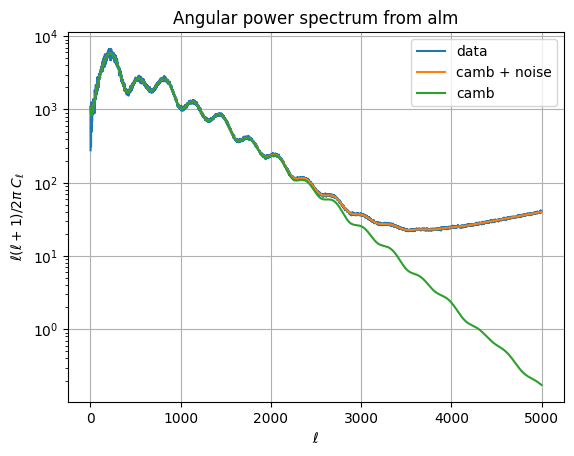

In [77]:
if gen_alms:
    # Each alm takes ~30Mb at 1024. This is fast enough we don't need to parallelize even for very large datasets
    alms = np.array([ksw_data.compute_alm_sim(False) 
                     for _ in tqdm(range(s.nsims), desc='a_lm progress')
                     ], dtype=s.c_dtype)

    # Make sure we dont get error from the beam_ell being a vector
    beam_ell_2d = np.atleast_2d(beam_ell)

    # KSW expects the alms to be coevolved with the beam
    for i in range(s.nsims):
        for j in range(s.npol):
            alms[i, j] = hp.almxfl(alms[i, j], beam_ell_2d[j]**-1)

    sdata = {}
    sdata['alm'] = alms
    sdata['settings'] = s.settings
    save_data(s.alm_file, sdata, verbose=s.verbose)

    if s.debug:
        nplots = 1
        random_indices = [(randint(s.nsims), randint(s.npol)) for _ in range(nplots)]
        for sim, pol in random_indices:
            plot_cl_alm(alms[sim, pol], s, c_ells=c_ells, save_name=f'{s.name}-alm_{sim}-{pol}')


2023-07-27 11:45:10.032060: Starting almng...


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:  1.9min
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed: 10.6min
[Parallel(n_jobs=10)]: Done 430 tasks      | elapsed: 25.0min
[Parallel(n_jobs=10)]: Done 780 tasks      | elapsed: 45.1min
[Parallel(n_jobs=10)]: Done 1199 out of 1199 | elapsed: 69.1min finished


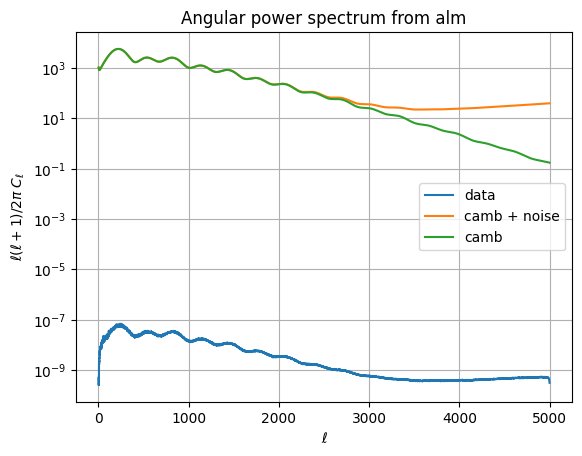

In [78]:
def get_alm(alm, bl_div_cl, alpha_l, r, dr):
    Balm = hp.almxfl(alm, bl_div_cl, inplace=False)
    B = hp.alm2map(Balm, nside=s.nside, lmax=s.lmax, pol=False, inplace=True)
    inner = hp.map2alm(B**2, lmax=s.lmax, pol=False, use_pixel_weights=True)
    kernel = hp.almxfl(inner, alpha_l, inplace=True)
    return dr * r**2 * kernel

if gen_alms:
    vp('Starting almng...')
    for i in range(s.nsims):
        sim_data = np.zeros((s.npol, s.nelem), dtype=s.c_dtype)

        for pol in range(s.npol):
            alm_gen = Parallel(n_jobs=s.settings['nthreads_alm'], verbose=1, return_as="generator")(
                delayed(get_alm)(
                        alms[i, pol], 
                        bl_div_cl[ri, :, pol], 
                        alpha_l[ri, :, pol], 
                        radii[ri], 
                        drs[ri]) 
                    for ri in range(len(drs))
                )
            
            for alm in alm_gen:
                sim_data[pol] += alm
        save_data(s.alm_file, {'almng': np.reshape(sim_data, (1, s.npol, s.nelem))}, verbose=False)

        if s.debug:
            plot_cl_alm(sim_data[0], s, c_ells=c_ells, save_name=f'{s.name}-almng')

    os.replace(s.alm_file, s.alm_final_file)

    # if s.debug:
    #     monitor.join_and_plot(s.plot_dir, f'{s.name}-almng_memory')


 # Sims

In [83]:
# Just load everything into memory right now, shouldn't be much of a problem until >10k sims
ldata = load_data(s.alm_final_file, ['alm', 'almng'], verbose=s.verbose)
alms = ldata['alm']
almngs = ldata['almng']


Loading data alm from data/alm_cache/2048_T_1.alms.hdf5


ValueError: Key alm not found in data/alm_cache/2048_T_1.alms.hdf5

In [84]:
# This generates the patch shapes and WCSs for later
# We could probably get some memory improvements by changing from full-sky but its not a big deal

vp('Generating patch shapes and WCSs')
res = np.deg2rad(s.settings['patch_side_deg'] / s.nside) # TODO Look into better value for res
fs_shape, fs_wcs = enmap.fullsky_geometry(res, proj="car")
fs_map = enmap.empty(fs_shape, fs_wcs)
vp('Done!')

ps_rad = np.deg2rad(s.settings['patch_side_deg'])

patch_shapes = []
patch_wcss = []
vp(f'Generating {s.npatches} patch geometry...')
for counter in np.arange(s.npatches//2):
    # [[dec_min,ra_min],[dec_max,ra_max]]
    top = [[0, ps_rad * counter], [ps_rad, ps_rad * (counter + 1)]]
    gs,w = enmap.geometry(pos=top, res=res, proj="car")
    patch_shapes.append(gs)
    patch_wcss.append(w)

    bottom = [[-ps_rad, ps_rad * counter], [0, ps_rad * (counter + 1)]]
    gs, w = enmap.geometry(pos=bottom, res=res, proj="car")
    patch_shapes.append(gs)
    patch_wcss.append(w)
vp('Done!')


2023-07-27 13:10:35.382068: Generating patch shapes and WCSs
2023-07-27 13:10:35.388469: Done!
2023-07-27 13:10:35.388644: Generating 10 patch geometry...
2023-07-27 13:10:35.394169: Done!


In [85]:
## Finally we can generate the patches

def cutSqPatches_lenspyx(s, fs_shape, fs_wcs, fs_map, pshapes, pwcs, cl_phi, alm, fnl, alm_ng):
    alms = alm + fnl * alm_ng

    lmax_unl = s.lmax # needs buffer???
    epsilon = 1e-6
    
    # Create a full sky map with lenspyx
    geom_info = ("healpix",{"nside": s.nside})
    plm = lenspyx.utils_hp.synalm(cl_phi, lmax=lmax_unl, mmax=lmax_unl)
    dlm = lenspyx.utils_hp.almxfl(plm, np.sqrt(np.arange(lmax_unl + 1, dtype=float) * np.arange(1, lmax_unl + 2)), None, False)
    # maps = lenspyx.utils_hp.synalm(cl_phi, lmax=lmax_unl, verbose=1, geometry=geom_info)

    # geom = lenspyx.get_geom(geom_info)
    # Tunl = geom.alm2map(tlm_unl, lmax_unl, mmax_unl, nthreads=os.cpu_count())
    Tlen = lenspyx.alm2lenmap(alms, dlm, geometry=geom_info, nthreads=1, verbose=1, epsilon=epsilon, pol=False)

    hp.mollview(Tlen)

    from pixell import reproject
    tm = reproject.healpix2map(Tlen, fs_shape, fs_wcs)
    
    plot_cl_map(tm, fs_wcs, s, c_ells=c_ells)

    patches = []
    for i in range(s.npatches):
        # lenspyx does not support projecting map to a different shape and wcs
        patch = tm.project(pshapes[i], pwcs[i]) # Not supported
        patches.append(patch)
        
    return np.ascontiguousarray(patches)

def cutSqPatches_pixell(s, fs_shape, fs_wcs, fs_map, pshapes, pwcs, cl_phi, alm, fnl, alm_ng):
    alms = alm + fnl * alm_ng

    # if s.debug:
    #     plot_cl_alm(alms, s, c_ells=c_ells, save_name=f'{s.name}-{fnl}-alm_prime')
    
    fs_map = enmap.empty(fs_shape, fs_wcs)
    car_map = curvedsky.alm2map(alms, fs_map)

    if s.lensing:
        phi_map = curvedsky.rand_map(fs_shape, fs_wcs, cl_phi)
        grad_phi = enmap.grad(phi_map)
        car_map = lensing.lens_map(car_map, grad_phi)

    # if s.debug:
    #     plot_cl_map(car_map, fs_wcs, s, c_ells=c_ells, save_name=f'{s.name}-{fnl}-full-sky')

    patches = []
    for i in range(s.npatches):
        patch = car_map.project(pshapes[i], pwcs[i]) # type: ignore
        patches.append(patch)
        
    return patches

cl_phi = ksw_data.cosmology._camb_data.get_lens_potential_cls(s.lmax, CMB_unit='muK', raw_cl=True)
cutPatches = partial(cutSqPatches_lenspyx, s, fs_shape, fs_wcs, fs_map, patch_shapes, patch_wcss, cl_phi[:,0])

# if s.debug:
#     monitor = MemoryMonitor()

vp('Generating patches')
fnls = uniform(s.settings['fnl_range'][0], s.settings['fnl_range'][1], (s.nsims,))
patches = np.empty((s.nsims, s.npol, s.npatches, s.nside, s.nside), dtype=s.r_dtype)
# with Parallel(s.settings['nthreads_sim'], verbose=1) as parallel:
#     for pol in range(s.npol):
#         patches[:, pol] = np.array(parallel(
#             delayed(cutPatches)(
#                 alms[i, pol], 
#                 fnls[i], 
#                 almngs[i, pol]) 
#             for i in range(s.nsims)
#         ))

for pol in range(s.npol):
    for i in range(s.nsims):
        patches[:, pol] = np.array(
            cutPatches(
                alms[i, pol], 
                fnls[i], 
                almngs[i, pol]) )
patches = patches.reshape((s.nsims, s.npol, s.npatches, s.nside, s.nside))
vp('Done!')


2023-07-27 13:10:36.786803: Generating patches


TypeError: 'NoneType' object is not subscriptable

In [ ]:
# if s.debug:
#     monitor.join_and_plot(s.plot_dir, f'{s.name}-patch_memory')


 # Save data

In [ ]:

sdata = {}
sdata['fnls'] = np.atleast_1d(fnls)
sdata['patches'] = np.array(patches)

if s.job_array_index is None or s.job_array_index == 1:
    # we only want one copy of the settings
    sdata['settings'] = s.settings

if os.path.isfile(s.data_file):
    vp('Removing stale data file', s.data_file)
    os.remove(s.data_file)

save_data(s.data_file, sdata, verbose=s.verbose)
os.replace(s.data_file, s.data_final_file)


In [ ]:
vp('Done with Generation!') 

if s.debug:
    monitor.join_and_plot(s.plot_dir, f'{s.name}-datagen')

# Just exit if we dont want the plots
if not s.debug:
    exit(0)        


 ---

 # Plots

In [ ]:
nplots = 10
random_indices = [(randint(s.nsims), randint(s.npol), randint(s.npatches)) for _ in range(nplots)]
# vp(random_indices)


In [ ]:
# Compute the grid size
grid_size = math.isqrt(len(random_indices))
if grid_size ** 2 < len(random_indices):
    grid_size += 1

# Create the grid of subplots
fig, axs = plt.subplots(grid_size, grid_size, sharex=True, sharey=True, figsize=(10, 10))

# If there's only one plot, put it in a list within a list to emulate a 2D list
if grid_size == 1:
    axs = [[axs]]

# Iterate over the random_indices
for idx, (i, p, n) in enumerate(random_indices):
    # Compute the subplot coordinates
    row = idx // grid_size
    col = idx % grid_size
    # Plot the image
    axs[row][col].imshow(patches[i, p, n])

# Hide the remaining unused subplots if any
if len(random_indices) < grid_size * grid_size:
    for idx in range(len(random_indices), grid_size * grid_size):
        row = idx // grid_size
        col = idx % grid_size
        axs[row][col].axis('off')

plt.title('Sample Patches')
save_plt(s.plot_dir, f'{s.name}-sample_patches')
plt.show()


In [ ]:
sim, pol, patch = random_indices[0]
plot_cl_map(patches[sim, pol, patch], patch_wcss[patch], s, c_ells=c_ells, save_name=f'{s.name}-cl_{sim}-{pol}-{patch}')


 # Goodbye